# Titanic (Kaggle) - Solution with more Exploratory Data Analysis
This notebook is an improvement on the minimal working product under 'Attempt1', based on the learnings from studying [https://www.kaggle.com/code/angqx95/data-science-workflow-top-2-with-tuning](angqx95's Gold-Medal Kaggle Notebook).

It taught me a lot, and this notebook is *"putting the theory into practice"*! 

## Contents
0. [Setup and Loading](#Sec-0)
1. [Understanding Data](#Sec-1)
    * [1.1 Univariate Analysis](#Sec-1.1)
    * [1.2 Bi-Variate Analysis](#Sec-1.2)

## [0. Setup and Loading](#Sec-0)

#### 0.0 Imports and Dataset Loading

In [52]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")

train = pd.read_csv('./data/train.csv', index_col=0)
test = pd.read_csv('./data/test.csv', index_col=0)

# Common to concatenate train and test together for visualisation, preprocessing, and feature engineering
# Be careful using these for model training though as not to leak data, or if we have errors it may be because we haven't considered that X and y in the below code are of different shapes.
X = pd.concat([train.drop('Survived', axis=1), test], axis=0)
y = train[['Survived']]

train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### 0.1 Finding NANs

In [53]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 1 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    1309 non-null   int64  
 1   Name      1309 non-null   str    
 2   Sex       1309 non-null   str    
 3   Age       1046 non-null   float64
 4   SibSp     1309 non-null   int64  
 5   Parch     1309 non-null   int64  
 6   Ticket    1309 non-null   str    
 7   Fare      1308 non-null   float64
 8   Cabin     295 non-null    str    
 9   Embarked  1307 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 102.4 KB


Note that the following features contain NaN values:
- Age
- Fare contains a single NaN
- Cabin
- Embarked contains two NaNs

#### 0.2 Isolating Numerical and Categorical Data

In [54]:
numeric_features = X.select_dtypes(exclude=['object', 'str']).copy()
cat_features = X.select_dtypes(include=['object', 'str']).copy()

# Helpful to decide whether they are categorical or numerical 
print(f"SibSp has {X['SibSp'].nunique()} unique values:", X['SibSp'].unique())
print(f"Pclass has {X['Pclass'].nunique()} unique values:", X['Pclass'].unique())

## select_dtypes only excludes string columns above - it can't detect integers that are actually categorical
## Hence, manually adjust this:
cat_features[['Pclass']] = X[['Pclass']]
numeric_features = numeric_features.drop(['Pclass'], axis=1)

numeric_features.head()



SibSp has 7 unique values: [1 0 3 4 2 5 8]
Pclass has 3 unique values: [3 1 2]


,Age,SibSp,Parch,Fare
PassengerId,,,,
1,22.0,1,0,7.2500
2,38.0,1,0,71.2833
3,26.0,0,0,7.9250
4,35.0,1,0,53.1000
5,35.0,0,0,8.0500


##### 0.2.1 Isolating Discrete and Continuous Numerical Data

In [55]:
disc_num_var = ['SibSp', 'Parch']
cont_num_var = []

for feature in numeric_features.columns:
    if feature not in disc_num_var:
        cont_num_var.append(feature)

cont_num_var

['Age', 'Fare']

## [1. Understanding Data](#Sec-1)

### [1.1 Univariate Analysis](#Sec-1.1)

#### 1.1.1 Numerical Features
Here we create histograms for each of the individual **continuous features**:

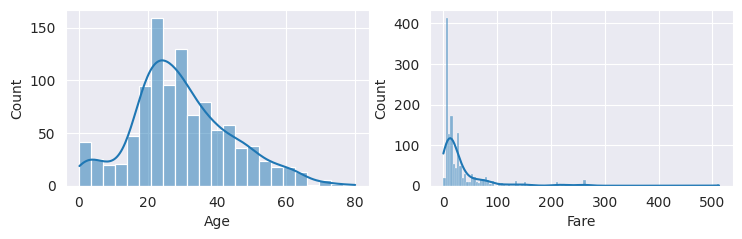

In [66]:
fig = plt.figure(figsize=(18,16))

for index,col in enumerate(cont_num_var):
    plt.subplot(6,4,index+1)

    # Plot each numeric continuous feature (drop any NaN's before plotting)
    sns.histplot(numeric_features.loc[:, col].dropna(), kde=True)

Both **Age** and **Fare** are positively skewed, but **Fare** has a far more significant skew magnitude.


Skew doesn't matter for tree-based models (Random Forest, XGBoost, LightGBM, etc.), but if doing Logistic Regression / SVM / KNN / Neural Nets, both skew and scale matter, so we'd want to apply a log transform to **Fare** (log1p since there may be zeros) then scale everything. (e.g. `df['Fare_log'] = np.log1p(df['Fare'])`)

We can analyse the individual **discrete features** using 'Count Plot' Bar Charts:

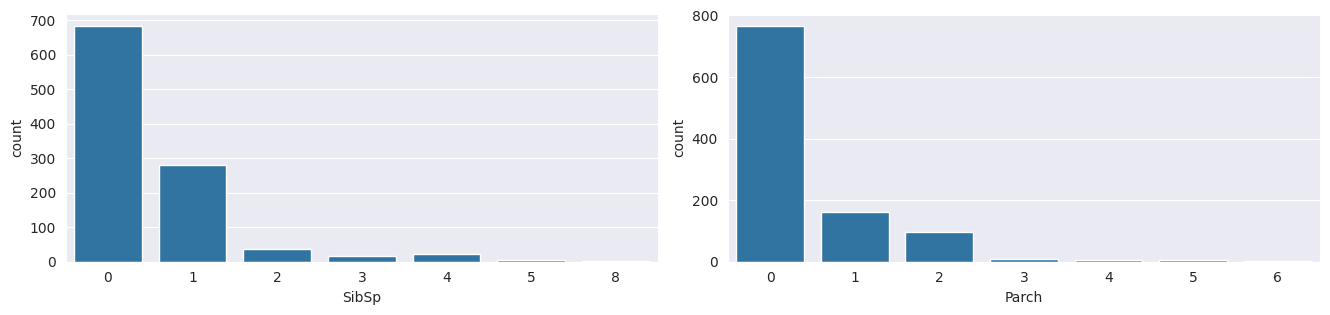

In [67]:
fig = plt.figure(figsize=(20,15))

for index,col in enumerate(disc_num_var):
    plt.subplot(5,3,index+1)

    # Plot each numeric continuous feature (drop any NaN's before plotting)
    sns.countplot(x=col, data=numeric_features.dropna())
fig.tight_layout(pad=1.0)

These findings show that results are heavily zero-dominated, and in context, 

### [1.2 Bi-Variate Analysis](#Sec-1.2)